In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("employees.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
rows, columns = df.shape

print("Number of Rows :", rows)
print("Number of Columns :", columns)

Number of Rows : 1470
Number of Columns : 35


In [6]:
print("Target Column :", "Attrition")
print(df["Attrition"].unique())

Target Column : Attrition
['Yes' 'No']


In [7]:
attrition_count = df["Attrition"].value_counts()

print(attrition_count)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [8]:
employees_left = attrition_count["Yes"]
total_employees = len(df)

attrition_rate = (employees_left / total_employees) * 100

print("Attrition Rate = {:.2f}%".format(attrition_rate))

Attrition Rate = 16.12%


In [9]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Number of Numeric Columns :", len(numeric_cols))
print("Number of Categorical Columns :", len(categorical_cols))

Number of Numeric Columns : 26
Number of Categorical Columns : 9


In [10]:
print("\nNumeric Columns:")
print(list(numeric_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))


Numeric Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [11]:
### OBSERVATION:
#The dataset contains 1,470 employee records and 35 features. 
#The target variable is Attrition, which indicates whether an employee left the company (Yes) or stayed (No). 
#The attrition rate is approximately 16.12%, meaning only a small portion of employees left the organization.
#This indicates that the dataset is imbalanced, as the number of employees who stayed is significantly higher than those who left. 
#Special care must therefore be taken during model training to handle class imbalance and avoid biased predictions.

In [12]:
# Checking whether any column contains missing values.
# Missing values can affect model performance if not handled properly.

print("Missing Values in Each Column:\n")
print(df.isnull().sum())

# Total missing values present in the dataset
print("\nTotal Missing Values :", df.isnull().sum().sum())

Missing Values in Each Column:

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInC

In [13]:
# Columns that do not contribute to prediction

columns_to_drop = [
    "EmployeeNumber",
    "Over18",
    "StandardHours",
    "EmployeeCount"
]

# Drop only if present in dataset

df.drop(
    columns=columns_to_drop,
    inplace=True,
    errors="ignore"
)

print("Updated Shape:", df.shape)

Updated Shape: (1470, 31)


In [14]:
# Convert target column into numerical form

df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

print(df["Attrition"].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [15]:
# Find all categorical columns

categorical_cols = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [16]:
# Convert categorical columns into numerical features

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Shape after Encoding:", df.shape)

Shape after Encoding: (1470, 45)


In [17]:
# X contains input features
# y contains target variable

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1470, 44)
Target Shape: (1470,)


In [18]:
from sklearn.preprocessing import StandardScaler

# Scale all feature values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling Completed")

Scaling Completed


In [19]:
# Convert scaled data back into dataframe

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


In [20]:
# Libraries required for EDA visualizations

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [21]:
print(df.columns)

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Res

In [22]:
# Creating a separate dataframe for EDA
# This keeps our model-ready data untouched

eda_df = pd.read_csv("employees.csv")

print("Dataset Shape:", eda_df.shape)
eda_df.head()

Dataset Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [23]:
# Calculating attrition percentage for each department

department_attrition = (
    eda_df.groupby("Department")["Attrition"]
          .apply(lambda x: (x == "Yes").mean() * 100)
          .sort_values(ascending=False)
)

print("Attrition Percentage by Department:")
print(department_attrition)

Attrition Percentage by Department:
Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


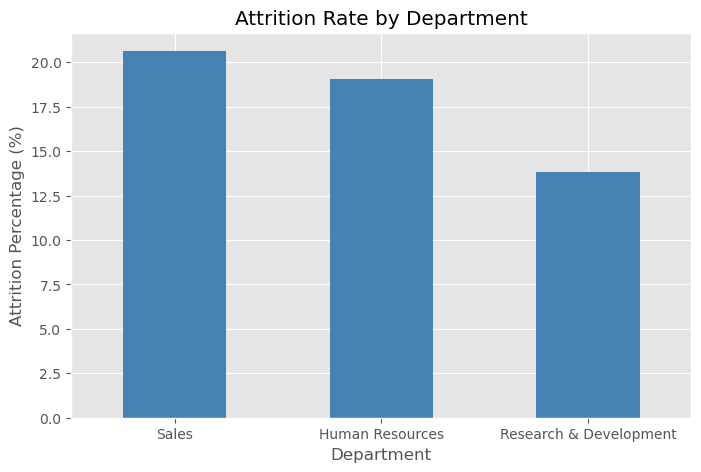

In [24]:
# Visualizing department-wise attrition

plt.figure(figsize=(8,5))

department_attrition.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Percentage (%)")
plt.xticks(rotation=0)

plt.show()

In [25]:
### OBSERVATION:
# The Sales department has the highest attrition rate at approximately 20.6%, followed by Human Resources at around 19.0%. 
# Research & Development has the lowest attrition rate at approximately 13.8%. 
# This indicates that employee turnover is more common in Sales and HR, suggesting that retention efforts should be prioritized in these departments.

In [26]:
# Calculate attrition percentage for each job role

jobrole_attrition = (
    eda_df.groupby("JobRole")["Attrition"]
          .apply(lambda x: (x == "Yes").mean() * 100)
          .sort_values(ascending=False)
)

print("Attrition Percentage by Job Role:")
print(jobrole_attrition)

Attrition Percentage by Job Role:
JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


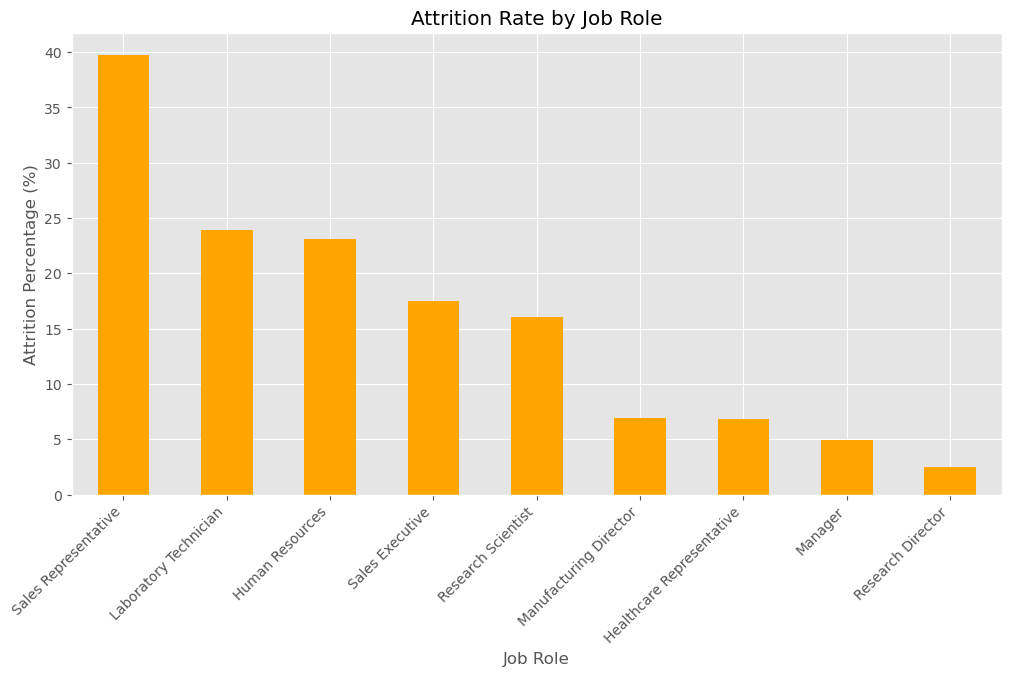

In [27]:
# Visualize attrition percentage by job role

plt.figure(figsize=(12,6))

jobrole_attrition.plot(
    kind="bar",
    color="orange"
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Percentage (%)")
plt.xticks(rotation=45, ha="right")

plt.show()

In [28]:
### OBSERVATION:
# Sales Representatives have the highest attrition rate at approximately 40%,
# indicating that employees in this role are significantly more likely to leave the organization.
# Laboratory Technicians and Human Resources employees also show relatively high attrition rates,
# with values around 24% and 23% respectively.
# Research Directors, Managers, and Healthcare Representatives have the lowest attrition rates,
# suggesting better employee retention in these positions.
# These findings indicate that retention efforts should primarily focus on Sales Representatives
# and other high-turnover job roles to reduce employee attrition.

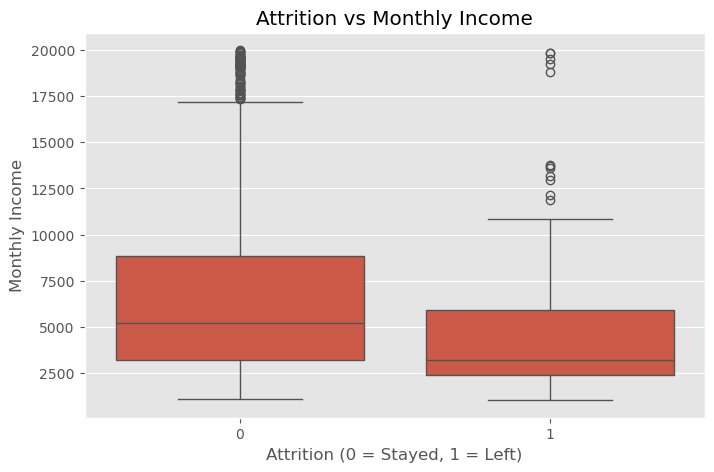

In [29]:
# Comparing monthly income of employees who left vs stayed

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Attrition vs Monthly Income")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")

plt.show()

In [30]:
### OBSERVATION:
# Employees who left the company generally have a lower monthly income compared to employees who stayed.
# The median monthly income of employees with Attrition = 1 is noticeably lower than that of employees with Attrition = 0.
# This suggests that compensation plays an important role in employee retention.
# However, a few high-income employees also left the organization, indicating that salary alone does not fully explain attrition.
# Other factors such as job satisfaction, overtime, and work-life balance may also influence employee turnover.

Attrition Percentage by Work-Life Balance:
WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


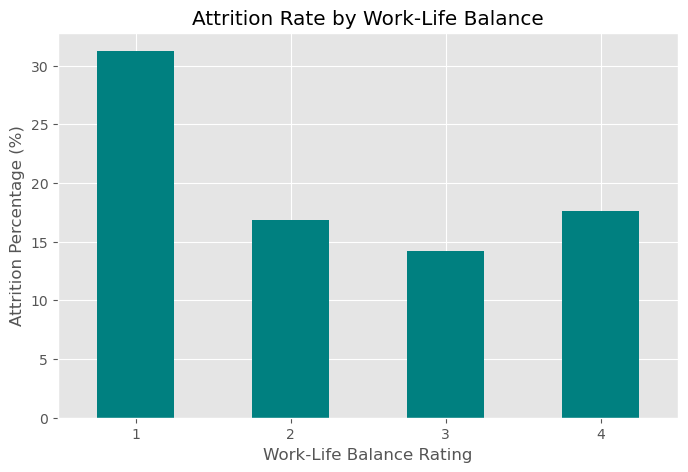

In [31]:
# Calculate attrition percentage for each Work-Life Balance rating

wlb_attrition = (
    df.groupby("WorkLifeBalance")["Attrition"]
    .mean() * 100
)

print("Attrition Percentage by Work-Life Balance:")
print(wlb_attrition)

# Plot the results

plt.figure(figsize=(8,5))

wlb_attrition.plot(
    kind="bar",
    color="teal"
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Percentage (%)")
plt.xticks(rotation=0)

plt.show()

In [32]:
### OBSERVATION:
# Employees with the poorest Work-Life Balance rating (1) have the highest attrition rate at approximately 31.25%.
# Attrition decreases significantly as Work-Life Balance improves, reaching its lowest value of around 14.22% for rating 3.
# Employees reporting better work-life balance are generally less likely to leave the company.
# This suggests that maintaining a healthy balance between work and personal life plays an important role in employee retention.
# Improving work-life balance policies may help reduce employee attrition.

Attrition Percentage by Years at Company:
YearsAtCompany
0      36.363636
1      34.502924
2      21.259843
3      15.625000
4      17.272727
5      10.714286
6      11.842105
7      12.222222
8      11.250000
9       9.756098
10     15.000000
11      6.250000
12      0.000000
13      8.333333
14     11.111111
15      5.000000
16      8.333333
17     11.111111
18      7.692308
19      9.090909
20      3.703704
21      7.142857
22      6.666667
23     50.000000
24     16.666667
25      0.000000
26      0.000000
27      0.000000
29      0.000000
30      0.000000
31     33.333333
32     33.333333
33     20.000000
34      0.000000
36      0.000000
37      0.000000
40    100.000000
Name: Attrition, dtype: float64


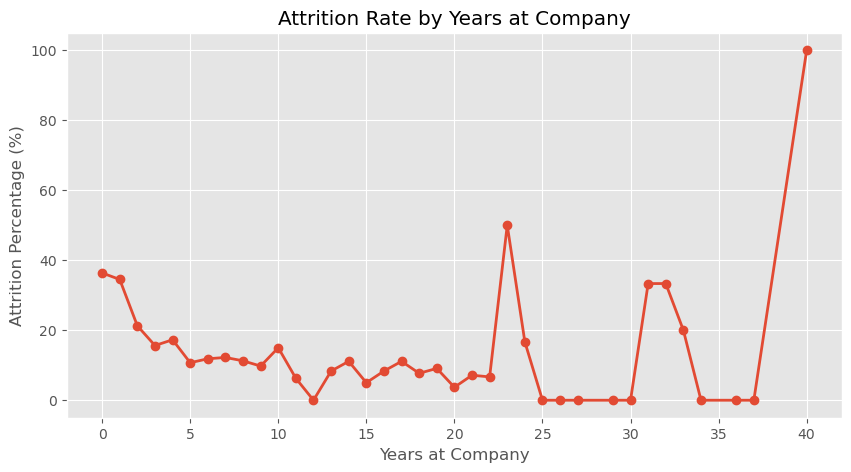

In [33]:
# Calculate attrition percentage for each YearsAtCompany value

years_attrition = (
    df.groupby("YearsAtCompany")["Attrition"]
    .mean() * 100
)

print("Attrition Percentage by Years at Company:")
print(years_attrition)

# Plot the trend

plt.figure(figsize=(10,5))

years_attrition.plot(
    kind="line",
    marker="o",
    linewidth=2
)

plt.title("Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Percentage (%)")

plt.grid(True)
plt.show()

In [34]:
### OBSERVATION:
# Employee attrition is highest during the first few years of employment, with attrition rates exceeding 30% for employees having 0–1 years at the company.
# As employee tenure increases, the attrition rate generally decreases, indicating better retention among experienced employees.
# Most long-term employees show relatively low attrition rates, suggesting that employees who remain with the company for several years are more likely to stay.
# This indicates that the initial years of employment are the most critical period for employee retention efforts.
# HR teams should focus on improving onboarding, engagement, and career development programs for newer employees.

In [35]:
### BUSINESS INSIGHTS FROM EDA

# 1. The Sales department has the highest attrition rate (~20.6%), indicating that employees in sales-related roles are more likely to leave compared to other departments.

# 2. Sales Representatives show the highest attrition rate (~39.8%) among all job roles, making them the most critical group for retention efforts.

# 3. Employees who leave the company generally have lower monthly incomes compared to employees who stay, suggesting compensation may influence attrition.

# 4. Employees with the lowest Work-Life Balance rating (Rating 1) have an attrition rate above 30%, which is significantly higher than other groups. This indicates work-life balance plays an important role in employee retention.

# 5. Attrition is highest during the early years of employment, especially within the first few years at the company. Employees who remain longer tend to stay with the organization, highlighting the importance of onboarding and early-career engagement programs.

In [36]:
# Import train-test split function
from sklearn.model_selection import train_test_split

# X contains all input features
# y contains the target variable (Attrition)

X = X_scaled
y = df["Attrition"]

# Split data into 80% training and 20% testing
# stratify=y keeps the same attrition ratio in both datasets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (1176, 44)
Testing Data Shape  : (294, 44)


In [37]:
# The dataset has been divided into training and testing sets.
# 80% of the data will be used for model training and 20% for evaluation.
# Stratified splitting ensures that the attrition distribution remains consistent
# across both training and testing datasets.

In [38]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
# class_weight='balanced' helps handle class imbalance
log_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=2000
)

# Train the model
log_model.fit(X_train, y_train)

# Make predictions on test data
y_pred_log = log_model.predict(X_test)

# Predict probabilities (needed later for ROC-AUC)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [39]:
# Logistic Regression is used as a baseline classification model.
# The class_weight='balanced' parameter gives extra importance to
# employees who left the company, helping the model learn from the
# minority class more effectively.

In [40]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [41]:
# Random Forest combines multiple decision trees to improve prediction accuracy.
# It can capture complex relationships between employee attributes and attrition.

In [42]:
# Import Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

# Create Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [43]:
# Gradient Boosting builds trees sequentially, where each new tree
# tries to correct the errors made by previous trees.
# It often provides strong predictive performance on structured datasets.

In [44]:
# Import evaluation metrics
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Create an empty list to store results
results = []

# Logistic Regression Metrics
results.append([
    "Logistic Regression",
    precision_score(y_test, y_pred_log),
    recall_score(y_test, y_pred_log),
    f1_score(y_test, y_pred_log),
    roc_auc_score(y_test, y_prob_log)
])

# Random Forest Metrics
results.append([
    "Random Forest",
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf),
    roc_auc_score(y_test, y_prob_rf)
])

# Gradient Boosting Metrics
results.append([
    "Gradient Boosting",
    precision_score(y_test, y_pred_gb),
    recall_score(y_test, y_pred_gb),
    f1_score(y_test, y_pred_gb),
    roc_auc_score(y_test, y_prob_gb)
])

# Convert results into dataframe
comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

comparison_df

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.341176,0.617021,0.439394,0.798605
1,Random Forest,0.571429,0.085106,0.148148,0.771643
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


In [45]:
# Observation:
# Logistic Regression achieved the best overall performance with the
# highest Recall (0.617), F1 Score (0.439), and ROC-AUC Score (0.799).
# Since employee attrition prediction focuses on identifying employees
# who may leave, Recall is particularly important.
# Therefore, Logistic Regression is selected as the best model.


In [50]:
## Confusion Matrix for Logistic Regressiont

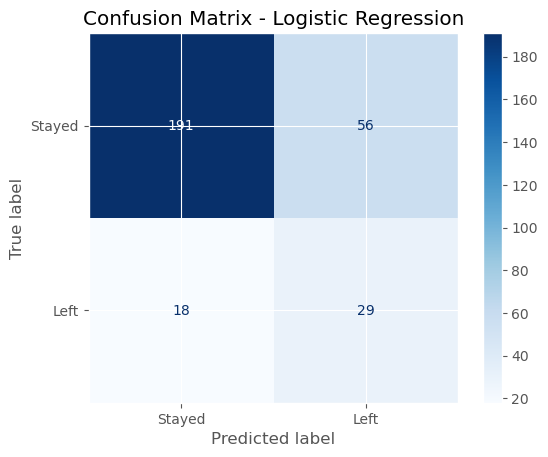

In [48]:
# Import libraries required for evaluating classification models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions on the test dataset using Logistic Regression
# The model predicts whether an employee will stay (0) or leave (1)
y_pred_log = log_model.predict(X_test)

# Create the confusion matrix by comparing
# actual labels with predicted labels
cm_log = confusion_matrix(y_test, y_pred_log)

# Display the confusion matrix in graphical form
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["Stayed", "Left"]
)

# Plot the confusion matrix
disp.plot(cmap="Blues")

# Add a suitable title
plt.title("Confusion Matrix - Logistic Regression")

# Display the graph
plt.show()

In [49]:
# Observation:
# The Logistic Regression model correctly classified 191 employees
# who stayed in the company and 29 employees who actually left.
#
# It incorrectly predicted 56 employees as leaving
# when they actually stayed.
#
# It also failed to identify 18 employees who actually left,
# predicting that they would stay.
#
# Since the objective of attrition prediction is to identify
# employees who are likely to leave, Logistic Regression
# demonstrates good performance by successfully detecting
# a large proportion of employee attrition cases.

In [52]:
## Confusion Matrix for Random Forest

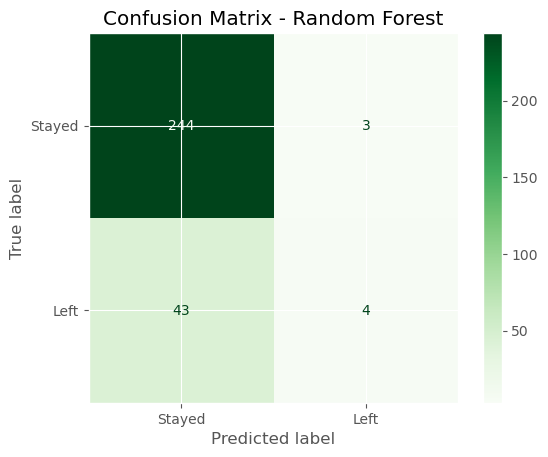

In [53]:
# Import libraries required for creating the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions on the test dataset using Random Forest
# The model predicts whether an employee will stay (0) or leave (1)
y_pred_rf = rf_model.predict(X_test)

# Create the confusion matrix by comparing
# actual values with predicted values
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Stayed", "Left"]
)

# Plot the confusion matrix
disp.plot(cmap="Greens")

# Add a title to the graph
plt.title("Confusion Matrix - Random Forest")

# Display the graph
plt.show()

In [56]:
# Observation:
# The Random Forest model correctly classified 244 employees
# who stayed in the company and 4 employees who actually left.
#
# It incorrectly predicted 3 employees as leaving
# when they actually stayed.
#
# It also failed to identify 43 employees who actually left,
# predicting that they would stay.
#
# Compared to Logistic Regression, Random Forest achieved
# higher accuracy for employees who stayed but detected
# significantly fewer employees who actually left.
#
# This is reflected in its lower Recall score, indicating
# that the model missed many actual attrition cases.
#
# Therefore, although Random Forest performed well for the
# majority class, it is less suitable for employee attrition
# prediction where identifying employees likely to leave is
# more important than predicting employees who stay.

In [58]:
## Confusion Matrix for Gradient Boosting

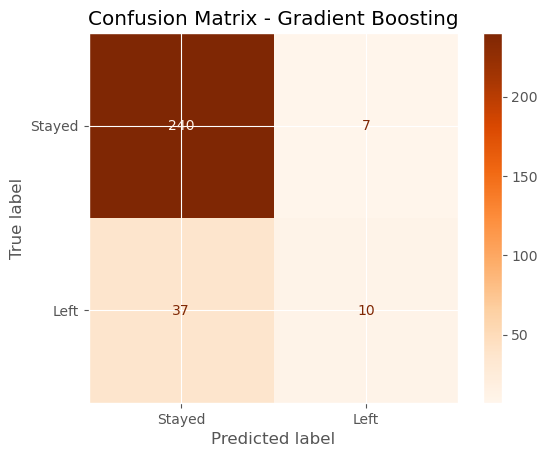

In [59]:
# Import libraries required for creating the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions on the test dataset using Gradient Boosting
# The model predicts whether an employee will stay (0) or leave (1)
y_pred_gb = gb_model.predict(X_test)

# Create the confusion matrix by comparing
# actual values with predicted values
cm_gb = confusion_matrix(y_test, y_pred_gb)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=["Stayed", "Left"]
)

# Plot the confusion matrix
disp.plot(cmap="Oranges")

# Add a suitable title
plt.title("Confusion Matrix - Gradient Boosting")

# Display the graph
plt.show()

In [60]:
# Observation:
# The Gradient Boosting model correctly classified 240 employees
# who stayed in the company and 10 employees who actually left.
#
# It incorrectly predicted 7 employees as leaving
# when they actually stayed.
#
# It also failed to identify 37 employees who actually left,
# predicting that they would stay.
#
# Compared to Random Forest, Gradient Boosting detected
# more employees who left the company. However, it still
# identified fewer attrition cases than Logistic Regression.
#
# Therefore, Gradient Boosting achieved moderate performance,
# but Logistic Regression remains the most suitable model
# for employee attrition prediction because of its higher
# Recall and better ability to identify employees at risk of leaving.

In [61]:
# Best Model Selection

# Logistic Regression is selected as the best-performing model
# for employee attrition prediction.

# It achieved the highest Recall (0.617), F1 Score (0.439),
# and ROC-AUC Score (0.799) among the three models.

# Although Gradient Boosting and Random Forest obtained
# higher Precision scores, both models failed to identify
# many employees who actually left the company, resulting
# in very low Recall values.

# In employee attrition prediction, correctly identifying
# employees who are likely to leave is more important than
# minimizing false alarms.

# Therefore, Logistic Regression is the most suitable model
# because it successfully detects a larger number of employees
# at risk of leaving, making it more useful for HR teams to
# plan employee retention strategies.

In [62]:
# Import pandas for creating a feature importance table
import pandas as pd

# Extract feature names and their corresponding coefficients
# Larger absolute coefficient values indicate greater influence
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

# Calculate the absolute coefficient values
# This helps rank features based on overall importance
feature_importance["Importance"] = feature_importance["Coefficient"].abs()

# Sort features from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 most influential features
print("Top 10 Most Important Features:")
feature_importance.head(10)

Top 10 Most Important Features:


,Feature,Coefficient,Importance
34,JobRole_Laboratory Technician,0.797874,0.797874
43,OverTime_Yes,0.766412,0.766412
23,BusinessTravel_Travel_Frequently,0.719335,0.719335
7,JobLevel,0.659189,0.659189
16,TotalWorkingYears,-0.656931,0.656931
40,JobRole_Sales Representative,0.552515,0.552515
24,BusinessTravel_Travel_Rarely,0.511649,0.511649
27,EducationField_Life Sciences,-0.506505,0.506505
21,YearsSinceLastPromotion,0.500389,0.500389
26,Department_Sales,0.481690,0.481690


In [64]:
# Observation:
# Logistic Regression assigns a coefficient to every feature.
#
# Features with larger absolute coefficient values have a
# stronger influence on predicting employee attrition.
#
# The table above lists the Top 10 most important features
# that contribute most to an employee leaving or staying.
#
# These features can help HR teams understand the primary
# factors affecting employee retention and support
# better workforce planning.

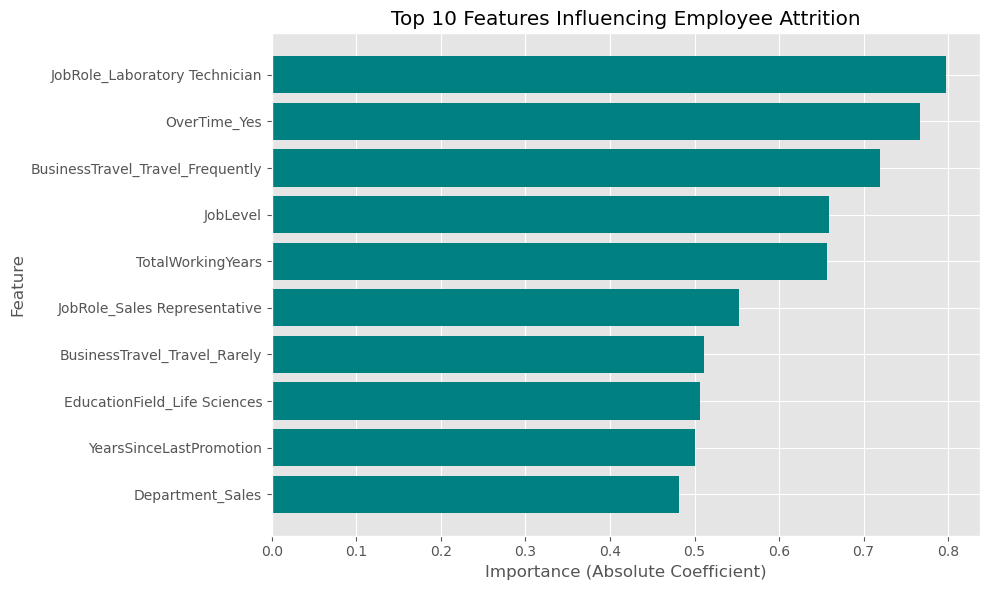

In [65]:
# Import plotting library
import matplotlib.pyplot as plt

# Plot Top 10 important features
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance.head(10)["Feature"],
    feature_importance.head(10)["Importance"],
    color="teal"
)

# Display the most important feature at the top
plt.gca().invert_yaxis()

# Add chart title and labels
plt.title("Top 10 Features Influencing Employee Attrition")
plt.xlabel("Importance (Absolute Coefficient)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [66]:
# Observation:
# The most influential factor affecting employee attrition is
# JobRole_Laboratory Technician, followed by Overtime_Yes
# and BusinessTravel_Travel_Frequently.
#
# Employees working overtime, travelling frequently,
# and belonging to certain job roles are more likely
# to leave the company.
#
# Job Level, Total Working Years, and Years Since Last Promotion
# also have a significant influence on attrition.
#
# These findings suggest that workload, career growth,
# and job responsibilities are key drivers of employee turnover.

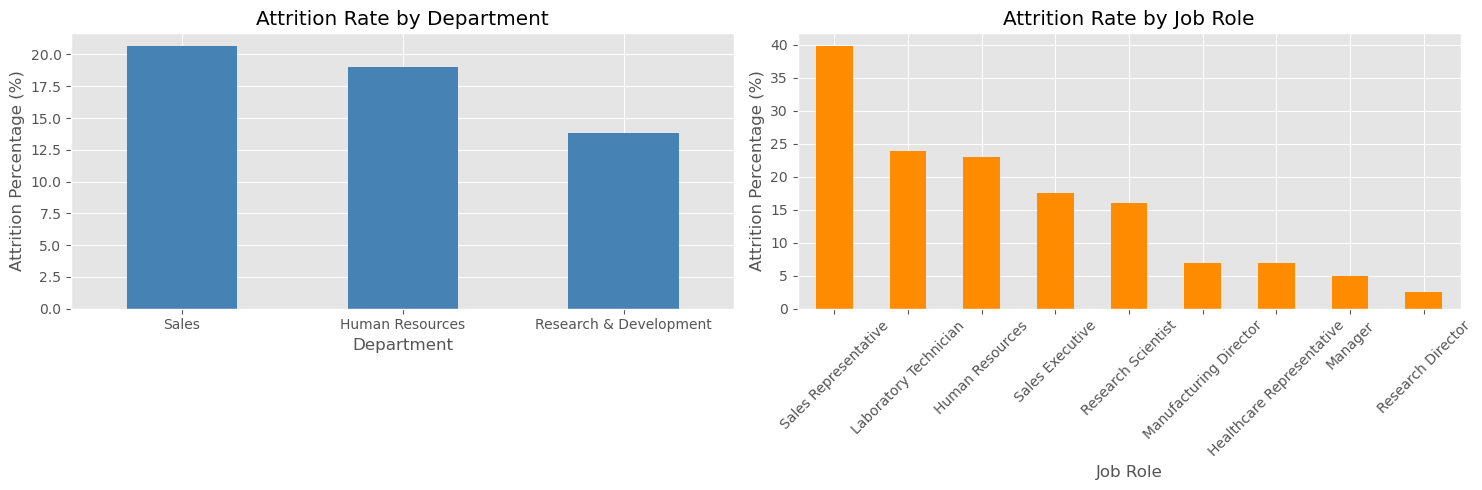

In [67]:
# Chart 1: Attrition Rate by Department and Job Role

import matplotlib.pyplot as plt

# Create one figure with two charts
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# -----------------------------
# Chart 1A: Attrition by Department
# -----------------------------
department_attrition.plot(
    kind="bar",
    color="steelblue",
    ax=axes[0]
)

axes[0].set_title("Attrition Rate by Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Attrition Percentage (%)")
axes[0].tick_params(axis="x", rotation=0)

# -----------------------------
# Chart 1B: Attrition by Job Role
# -----------------------------
jobrole_attrition.plot(
    kind="bar",
    color="darkorange",
    ax=axes[1]
)

axes[1].set_title("Attrition Rate by Job Role")
axes[1].set_xlabel("Job Role")
axes[1].set_ylabel("Attrition Percentage (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [68]:
# Observation:
# Sales has the highest attrition rate among all departments,
# while Research & Development has the lowest.
#
# Among job roles, Sales Representative experiences the highest
# employee attrition, followed by Laboratory Technician and
# Human Resources.
#
# This indicates that employee turnover is concentrated in
# customer-facing and operational roles, suggesting that
# retention strategies should primarily focus on these groups.

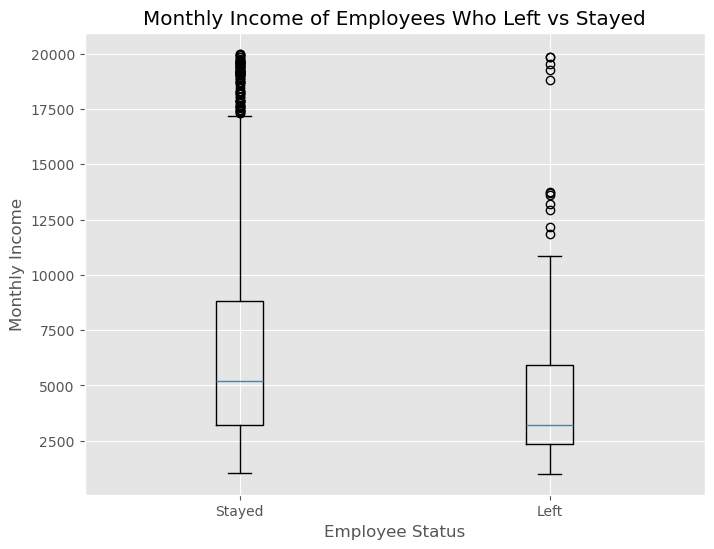

In [72]:
# Chart 2: Monthly Income of Employees Who Left vs Stayed

# Import visualization library
import matplotlib.pyplot as plt

# Create a box plot to compare the monthly income
# of employees who stayed (Attrition = 0)
# and employees who left (Attrition = 1)

plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        df[df["Attrition"] == 0]["MonthlyIncome"],
        df[df["Attrition"] == 1]["MonthlyIncome"]
    ],
    tick_labels=["Stayed", "Left"]   # Updated parameter (replaces 'labels')
)

# Add chart title and axis labels
plt.title("Monthly Income of Employees Who Left vs Stayed")
plt.xlabel("Employee Status")
plt.ylabel("Monthly Income")

# Display the chart
plt.show()

In [73]:
# Observation:
# Employees who left the company generally have a lower median monthly income
# compared to employees who stayed.
#
# Employees who stayed show a wider salary distribution,
# including many high-income outliers.
#
# This suggests that lower-paid employees are relatively
# more likely to leave the organization.
#
# Therefore, compensation may be one of the factors
# influencing employee attrition.

<Figure size 600x600 with 0 Axes>

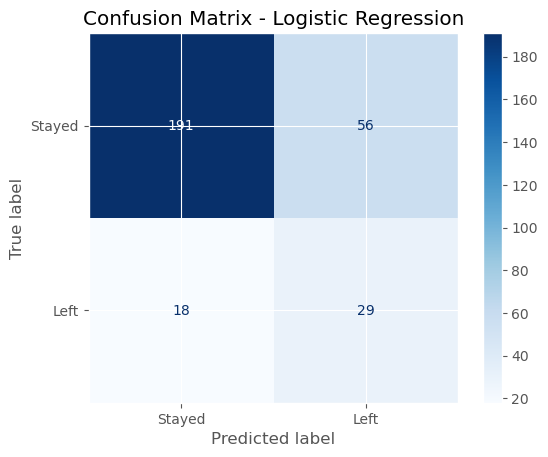

In [74]:
# Chart 3: Confusion Matrix Heatmap (Best Model)

# Import required libraries
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions using the best model (Logistic Regression)
y_pred_log = log_model.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Display the confusion matrix as a heatmap
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [75]:
# Observation:
# The Logistic Regression model correctly classified 191 employees
# who stayed in the company and 29 employees who left.
#
# It incorrectly predicted 56 employees as leaving
# when they actually stayed.
#
# The model also failed to identify 18 employees
# who actually left the company.
#
# Since employee attrition prediction focuses on identifying employees
# who are likely to leave, the model achieves a good Recall score,
# making it suitable for HR retention planning.

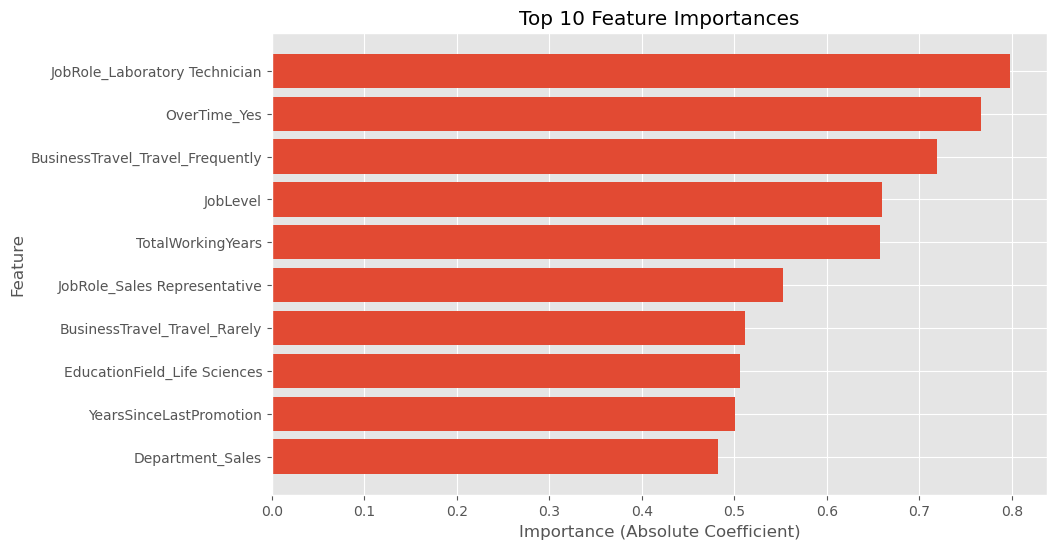

In [77]:
# Chart 4: Top 10 Feature Importances

# Import visualization library
import matplotlib.pyplot as plt

# Select the top 10 most important features
top10 = feature_importance.head(10)

# Create a horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

# Display the most important feature at the top
plt.gca().invert_yaxis()

# Add chart title and axis labels
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance (Absolute Coefficient)")
plt.ylabel("Feature")

# Display the chart
plt.show()

In [78]:
# Observation:
# This chart provides a visual representation of the Top 10 most
# important features identified during Task 5.
#
# JobRole_Laboratory Technician, OverTime_Yes,
# and BusinessTravel_Travel_Frequently are the most influential
# factors affecting employee attrition.
#
# Features such as JobLevel, TotalWorkingYears,
# and YearsSinceLastPromotion also have a significant impact,
# indicating that both job characteristics and career progression
# contribute to employee turnover.
#
# The horizontal bar chart makes it easier to compare the relative
# importance of each feature and supports the conclusions drawn
# from the feature importance analysis.

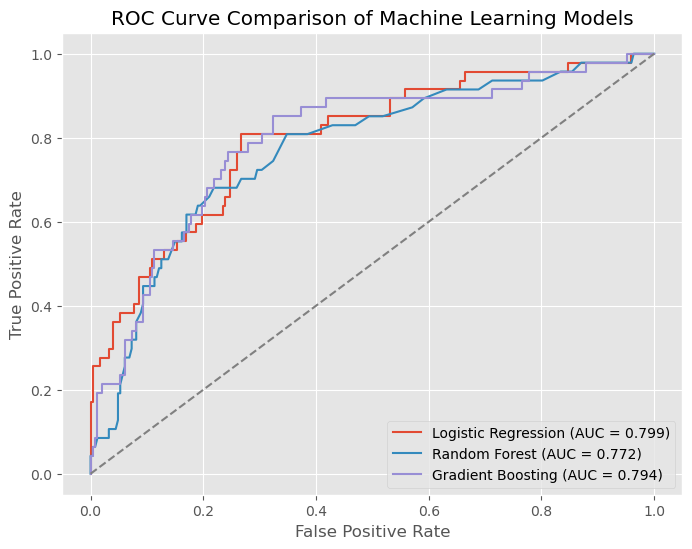

In [79]:
# Chart 5 (Bonus): ROC Curve Comparison of All Models

# Import required libraries
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
# for each of the three models

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

# Calculate Area Under the Curve (AUC)
auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_gb = auc(fpr_gb, tpr_gb)

# Create the ROC Curve comparison plot
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log,
         label=f"Logistic Regression (AUC = {auc_log:.3f})")

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC = {auc_rf:.3f})")

plt.plot(fpr_gb, tpr_gb,
         label=f"Gradient Boosting (AUC = {auc_gb:.3f})")

# Plot the random guessing reference line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

# Add chart title and axis labels
plt.title("ROC Curve Comparison of Machine Learning Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Display the legend
plt.legend(loc="lower right")

# Display the chart
plt.show()

In [80]:
# Observation:
# The ROC Curve compares the classification performance of
# Logistic Regression, Random Forest, and Gradient Boosting models.
#
# Logistic Regression achieved the highest ROC-AUC score,
# indicating the best overall ability to distinguish between
# employees who stayed and employees who left the company.
#
# Gradient Boosting showed performance close to Logistic Regression,
# while Random Forest achieved the lowest ROC-AUC score.
#
# Overall, Logistic Regression demonstrated the most reliable
# classification performance and was selected as the best model
# for employee attrition prediction.